In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from IPython.display import display, Math

data = pd.DataFrame({'h':           [60.05, 60.4, 60.4, 60.4, 50.4], # in mm
                     'ID':          [9.5, 7.5, 7.75, 7.25, 16], 
                     'OD':          [14.75, 12.0, 12.0, 12.0, 21.5],
                     'thickness':   [np.mean([1.5, 1.5, 2.0]),
                                     np.mean([1.1, 1.5, 1.1, 1.9]),
                                     np.mean([1.5, 2.1]),
                                     np.mean([1.9, 2.0]),
                                     np.mean([2.1, 2.1, 2.5])]
                     })

for key, val in data.items():
    data[key] = val / 10
print(data)

       h     ID     OD  thickness
0  6.005  0.950  1.475   0.166667
1  6.040  0.750  1.200   0.140000
2  6.040  0.775  1.200   0.180000
3  6.040  0.725  1.200   0.195000
4  5.040  1.600  2.150   0.223333


In [2]:
epsilon = data['ID'] / data['OD']
thickness = data['OD'] - data['ID']

In [3]:
def od(h, m, b):
    return 2 * (m * h + b)

popt, pcov = curve_fit(od, data['h'], data['OD'])

In [4]:
md_math = f"$OD = {popt[0]}h + {popt[1]}$"
display(Math(md_math))

<IPython.core.display.Math object>

In [5]:
# Distance from stage to crossing pt at OD = 0
OD = 0
h_0 = ((OD + 2.5 / 10) - popt[1]) / popt[0]

# Distance from stage to objective at OD = -2.5
OD = -2.5 / 10
h_obj = ((OD + 2.5 / 10) - popt[1]) / popt[0]

# This will assume the obj is filled. To fix this, we can measure the height to the objective and remove the -2.5 mm assumption
WD = h_obj - h_0
print(h_obj, WD)

# Alternatively, we can assume the manufacturer WD of 2mm and solve
WD = 2 / 10
h_obj = h_0 + 2 / 10
print(h_obj, WD)

# Because of the disparity, we will use the one with 2mm WD and calculate diameters from there.
OD = od(h_obj, *popt)
print(f'{np.abs(OD)} will be the starting outer diameter of simulations')
THETA = np.arctan(-OD / (h_obj-h_0))
print(f'{THETA} will be the angle of simulations')

7.44363114247511 0.5573118140052289
7.086319328469881 0.2
0.3205672345588173 will be the starting outer diameter of simulations
-1.012992674814683 will be the angle of simulations


In [6]:
# ID will assume the same slope, but find a new y intercept in order to determine the acceptance diameter 
def id(h, b):
    return 2 * (popt[0] * h + b)

popt2, pcov = curve_fit(id, data['h'], data['ID'])

In [7]:
from IPython.display import display, Math
md_math = f"$ID = {popt[0]}h + {popt2[0]}$"
display(Math(md_math))

<IPython.core.display.Math object>

In [8]:
ID = id(h_obj, *popt2)
print(f'{np.abs(ID)} will be the starting inner diameter of simulations')

0.16443276544118213 will be the starting inner diameter of simulations


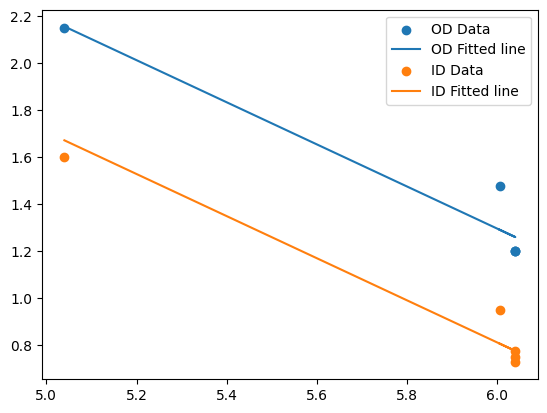

In [9]:
plt.figure()
ax = plt.axes()
ax.scatter(data['h'], data['OD'], label='OD Data')
ax.plot(data['h'], od(data['h'], *popt), label='OD Fitted line')
ax.scatter(data['h'], data['ID'], label='ID Data')
ax.plot(data['h'], id(data['h'], *popt2), label='ID Fitted line')
ax.legend()
plt.show()

In [42]:
def plot_beam(locations, directions):
    # Plot incident points
    fig, ax = plt.subplots(figsize=(6,6))
    ax.scatter(locations[:,0], locations[:,1], s=2, label="Sampled Points")
    ax.set_xlabel("X (cm)")
    ax.set_ylabel("Y (cm)")
    ax.set_title("Simulated beam footprint")
    ax.set_aspect('equal')
    plt.show()
    
    # 3D Quiver plot (direction vectors)
    fig = plt.figure(figsize=(7,7))
    ax = fig.add_subplot(111, projection='3d')
    
    # Plot points
    ax.scatter(*locations.T, s=2, label='Ring Points')
    
    # Plot direction vectors
    scale = 1  # Adjust arrow length for visibility
    ax.quiver(*locations.T, 
              *directions.T, 
              length=scale, normalize=True)
    ax.invert_zaxis()
    ax.set_xlabel("X")
    ax.set_ylabel("Y")
    ax.set_zlabel("Z")
    ax.set_title("3D Quiver Plot of Sampled Directions")
    ax.legend()
    ax.set_aspect('equal')
    plt.show()

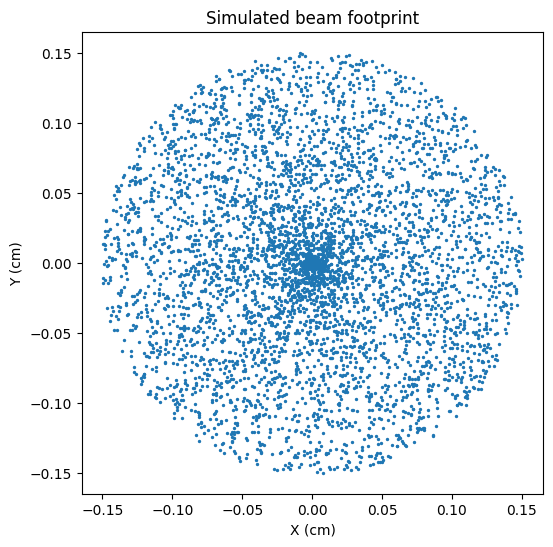

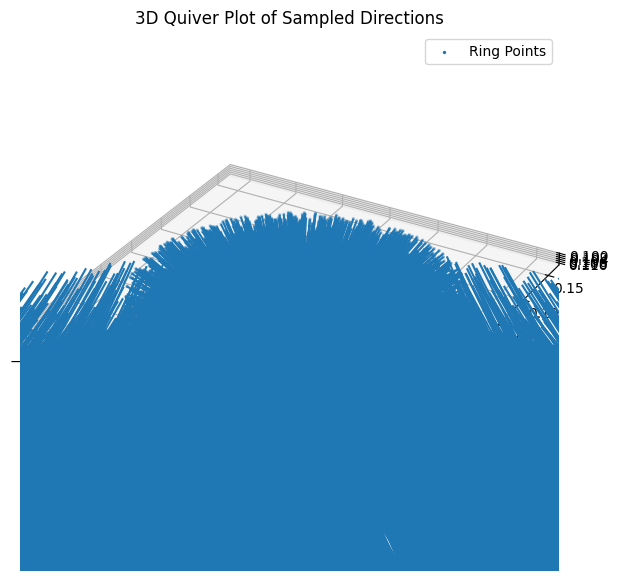

In [74]:
def create_darkfield_ring(rs, thetas):
    r_min, r_max = rs
    theta_min, theta_max = thetas
    def sampler(n):
        # Sample angle and radius for starting location
        phi = np.random.uniform(0, 2 * np.pi, n)
        r =np.sqrt(np.random.uniform(r_min ** 2, r_max ** 2, n))
    
        # Create ring
        x = r * np.cos(phi)
        y = r * np.sin(phi)
    
        # Sample injection angles directional cosines
        theta = np.random.uniform(theta_min, theta_max, n)
    
        # Compute directional cosines
        mu_x = np.sin(theta) * np.cos(phi)
        mu_y = np.sin(theta) * np.sin(phi)
        mu_z = np.cos(theta)
        directional_cosines = np.stack((mu_x, mu_y, mu_z), axis=1)
        location = np.stack((x, y, np.zeros(n)), axis=1) + directional_cosines * WD
        
        return location, directional_cosines 
    return sampler

# Generate samples
n_samples = 5000
locations, directions = create_darkfield_ring((ID, OD), (THETA, THETA))(n_samples)
plot_beam(locations, directions)

In [36]:
from photon_canon.hardware import oblique_beams

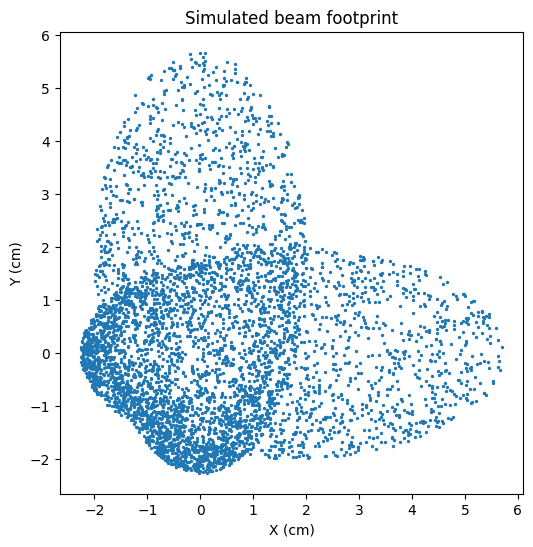

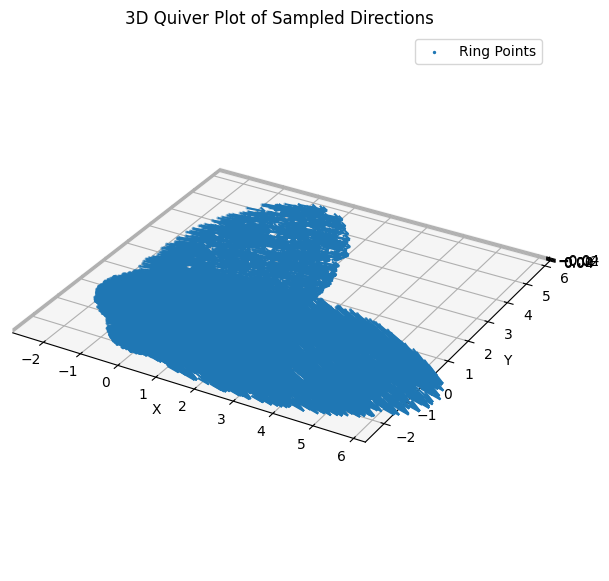

In [75]:
def create_oblique_sampler(gamma, w):
    def sampler(n):
        c = np.radians(gamma)

        # Sample radial positions within a circular beam profile
        r = w * np.sqrt(np.random.uniform(0, 1, n))  # Uniform distribution in area
        phi = np.random.uniform(0, 2 * np.pi, n)     # Uniform angular distribution

        # Calculate the offsets based on the radial distance and angle
        in_plane_offsets = r * np.cos(phi)
        out_of_plane_offsets = r * np.sin(phi)

        # Calculate incidence point on horizontal plane
        in_plane_incidence = in_plane_offsets + (r * np.sin(c)) - (w * np.sin(c) / 2)
        in_plane_incidence /= np.cos(c)
        out_of_plane_incidence = out_of_plane_offsets  # Out of plane location is unchanged

        # Select beam and input final outputs accordingly (beam0: xz plane; beam1: yz plane)
        beam = np.random.choice((0, 1), n)

        location_coordinates = np.zeros((n, 3))
        location_coordinates[:, 0] = np.where(beam == 0, in_plane_incidence, out_of_plane_incidence)
        location_coordinates[:, 1] = np.where(beam == 1, in_plane_incidence, out_of_plane_incidence)
        directional_cosines = np.cos(c) * np.ones((n, 3))
        directional_cosines[:, 0] = np.where(beam == 0, np.sin(c), 0)
        directional_cosines[:, 1] = np.where(beam == 1, np.sin(c), 0)

        return location_coordinates, directional_cosines
    return sampler

# Example usage
gamma = 60  # Angle of the beam with respect to the vertical (z-axis)
w = 2     # Beam width (radius)
n_photons = 5000  # Number of photons to sample

# Sample photons and plot
locations, directional_cosines = create_oblique_sampler(gamma, w)(n_photons)
plot_beam(locations, directional_cosines)